# ML Data Preparation — Benin Insights

In [1]:
from pathlib import Path
from typing import Dict, List
import io
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_CLEAN_PATH = PROJECT_ROOT / "data/processed/gdelt_benin_clean.csv"
RAW_ML_PATH = PROJECT_ROOT / "data/processed/ml_input_text.csv"
PROCESSED_PATH = PROJECT_ROOT / "data/processed/ml_input_text.csv"
REPORT_PATH = PROJECT_ROOT / "reports/ml_data_prep_summary.txt"

REQUIRED_COLUMNS: List[str] = [
    "SQLDATE",
    "Actor1Name",
    "Actor2Name",
    "EventCode",
    "EventBaseCode",
    "EventRootCode",
    "GoldsteinScale",
    "AvgTone",
    "NumArticles",
    "ActionGeo_FullName",
    "SOURCEURL",
    ]

print('Project root:', PROJECT_ROOT)
print('Using cleaned source:', RAW_CLEAN_PATH)

Project root: /home/appolinaire/projects/benin-insights-challenge-team2
Using cleaned source: /home/appolinaire/projects/benin-insights-challenge-team2/data/processed/gdelt_benin_clean.csv


In [2]:
if not RAW_CLEAN_PATH.exists():
    raise FileNotFoundError(f"Cleaned source not found: {RAW_CLEAN_PATH}")

df = pd.read_csv(RAW_CLEAN_PATH)

print('FILE:', RAW_CLEAN_PATH)
print('shape:', df.shape)

buf = io.StringIO()
df.info(buf=buf)
print('\n--- df.info() ---')
print(buf.getvalue())

print('\n--- df.describe() ---')
print(df.describe(include='all').transpose())

print('\n--- head(5) ---')
print(df.head(5).to_string(index=False))

print(f"\nmemory_usage (MB): {df.memory_usage(deep=True).sum()/1024**2:.2f}")

FILE: /home/appolinaire/projects/benin-insights-challenge-team2/data/processed/gdelt_benin_clean.csv
shape: (6647, 22)

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6647 entries, 0 to 6646
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Actor1Name             6647 non-null   object 
 1   Actor1CountryCode      6647 non-null   object 
 2   Actor2Name             6647 non-null   object 
 3   Actor2CountryCode      6647 non-null   object 
 4   EventCode              6647 non-null   int64  
 5   EventBaseCode          6647 non-null   int64  
 6   EventRootCode          6647 non-null   int64  
 7   GoldsteinScale         6647 non-null   float64
 8   NumArticles            6647 non-null   int64  
 9   AvgTone                6647 non-null   float64
 10  ActionGeo_FullName     6647 non-null   object 
 11  ActionGeo_CountryCode  6647 non-null   object 
 12  ActionGeo_Lat         

In [3]:
print('1. Période couverte')
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
print(f"  Min: {df['date_parsed'].min()}")
print(f"  Max: {df['date_parsed'].max()}")
print(f"  Durée: {(df['date_parsed'].max() - df['date_parsed'].min()).days} jours")

print('\n2. Distribution du sentiment (sentiment label)')
if 'sentiment' in df.columns:
    print(df['sentiment'].value_counts().sort_index())
else:
    print('  Colonne sentiment non trouvée; colonnes disponibles:', df.columns.tolist())

print('\n3. Top 10 sources (par domaine)')
df['domain'] = df['SOURCEURL'].str.split('/').str[2]
print(df['domain'].value_counts().head(10))

print('\n4. GoldsteinScale distribution (quantiles)')
print(df['GoldsteinScale'].describe())

print('\n5. Corrélation AvgTone (sentiment) vs GoldsteinScale (stabilité)')
corr = df[['AvgTone','GoldsteinScale']].corr()
print(corr)
print(f'\nCorrélation AvgTone-GoldsteinScale: {corr.iloc[0,1]:.3f}')
print('  → Corrélation modérée = deux signaux complémentaires à exploiter')

1. Période couverte
  Min: 2025-01-01 00:00:00
  Max: 2026-04-28 00:00:00
  Durée: 482 jours

2. Distribution du sentiment (sentiment label)
sentiment
neutre     1070
négatif    3360
positif    2217
Name: count, dtype: int64

3. Top 10 sources (par domaine)
domain
punchng.com                 447
dailypost.ng                426
nigerianobservernews.com    278
lanouvelletribune.info      236
allafrica.com               185
guardian.ng                 174
leadership.ng               153
www.thisdaylive.com         141
thesun.ng                   136
quicknews-africa.net        135
Name: count, dtype: int64

4. GoldsteinScale distribution (quantiles)
count    6647.000000
mean        0.620566
std         4.318423
min       -10.000000
25%        -2.000000
50%         1.900000
75%         3.400000
max        10.000000
Name: GoldsteinScale, dtype: float64

5. Corrélation AvgTone (sentiment) vs GoldsteinScale (stabilité)
                 AvgTone  GoldsteinScale
AvgTone         1.000000        0

# Volet 3 — Distribution temporelle mensuelle
Objectif: mesurer le volume par mois et detecter les pics (seuil moyenne + 1 sigma).

=== VOLUME PAR MOIS ===
date_parsed
2025-01    532
2025-02    363
2025-03    442
2025-04    421
2025-05    426
2025-06    209
2025-07    465
2025-08    324
2025-09    330
2025-10    373
2025-11    424
2025-12    901
2026-01    337
2026-02    335
2026-03    343
2026-04    422
Freq: M

=== PICS (moy+1σ) ===
date_parsed
2025-12    901
Freq: M


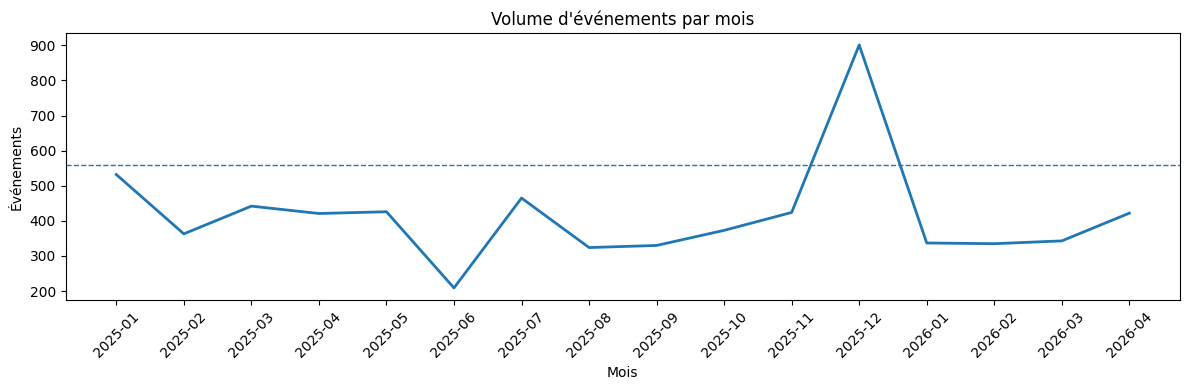

In [4]:
import pandas as pd

if "df" not in globals():
    raise RuntimeError("Exécuter d'abord les cellules 1 et 2 (chargement des données)")

if "date_parsed" not in df.columns:
    if "date" in df.columns:
        date_source = df["date"]
    elif "SQLDATE" in df.columns:
        date_source = df["SQLDATE"]
    else:
        raise ValueError("Colonne date absente (attendues: date, SQLDATE)")
    df["date_parsed"] = pd.to_datetime(date_source, errors="coerce")

if df["date_parsed"].isna().all():
    raise ValueError("Impossible de parser les dates (colonnes attendues: date, SQLDATE)")

year_month = df["date_parsed"].dt.to_period("M")
monthly_counts = year_month.value_counts().sort_index()

threshold: float = float(monthly_counts.mean() + monthly_counts.std(ddof=0))
peaks = monthly_counts[monthly_counts.gt(threshold)]

print("=== VOLUME PAR MOIS ===")
print(monthly_counts.to_string())

print("\n=== PICS (moy+1σ) ===")
print("Aucun" if peaks.empty else peaks.to_string())

try:
    import matplotlib.pyplot as plt

    x = monthly_counts.index.astype(str).tolist()
    y = monthly_counts.values.tolist()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(x, y, linewidth=2)
    ax.axhline(threshold, linestyle="--", linewidth=1)
    ax.set_title("Volume d'événements par mois")
    ax.set_xlabel("Mois")
    ax.set_ylabel("Événements")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    plt.show()
    plt.close(fig)
except ImportError:
    raise ImportError("matplotlib manquant. Installe via: pip install -r requirements.txt")

# Volet 4 — Evenements majeurs des mois de pic
Objectif: identifier les event_label dominants pour chaque mois de pic et les visualiser.


--- 2025-12 | n=901 ---
event_label
Déclaration publique       154
Consultation               154
Engagement diplomatique    109
Désapprobation              76
Appel / Demande             67
Coercition                  52
Accord / Coopération        43
Coopération                 38
Violence de masse           32
Coopération matérielle      30


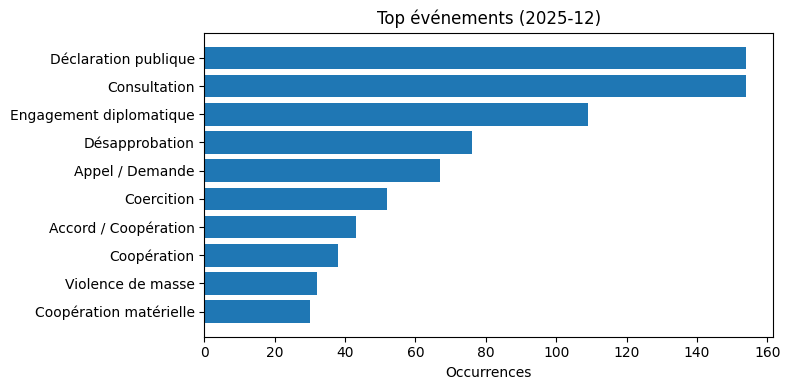

In [5]:
def _pick_first_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None

df_month = df.copy()
df_month["year_month"] = df_month["date_parsed"].dt.to_period("M")

event_col = _pick_first_col(df_month, ["event_label", "EventRootCode", "EventBaseCode", "EventCode"])
if event_col is None:
    raise ValueError("Aucune colonne événement trouvée (event_label, EventRootCode, EventBaseCode, EventCode)")

peak_months = list(peaks.index) if "peaks" in globals() else []
if not peak_months:
    print("Aucun mois de pic")
else:
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        raise ImportError("matplotlib manquant. Installe via: pip install -r requirements.txt")

    for m in peak_months:
        sub = df_month[df_month["year_month"] == m]
        top_events = sub[event_col].value_counts().head(10)

        print(f"\n--- {m} | n={len(sub)} ---")
        print(top_events.to_string())

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.barh(list(reversed(top_events.index.astype(str).tolist())), list(reversed(top_events.values.tolist())))
        ax.set_title(f"Top événements ({m})")
        ax.set_xlabel("Occurrences")
        fig.tight_layout()
        plt.show()
        plt.close(fig)

# Volet 5 — Focus compare (2025-01, 2025-06, 2025-07)
Objectif: investiguer le creux de juin 2025 et comparer volumes, sources et event_label dominants.

In [6]:
if "df" not in globals():
    raise RuntimeError("Exécuter d'abord les cellules de chargement des données")

if "date_parsed" not in df.columns:
    date_source = df["date"] if "date" in df.columns else df["SQLDATE"]
    df["date_parsed"] = pd.to_datetime(date_source, errors="coerce")

monthly_period = df["date_parsed"].dt.to_period("M")
month_key = monthly_period.astype(str)

months_to_investigate = ["2025-01", "2025-06", "2025-07"]
months_to_compare = ["2025-05", "2025-06", "2025-07"]

print("=== Comparatif rapide des volumes ===")
volume_compare = (
    df.assign(month=monthly_period)
      .groupby("month")
      .agg(rows=("event_label", "size"),
           articles=("NumArticles", "sum"),
           unique_urls=("SOURCEURL", "nunique"))
      .loc[pd.PeriodIndex(months_to_compare, freq="M")]
)
print(volume_compare)

for month in months_to_investigate:
    sub = df[month_key == month].copy()
    print(f"\n=== {month} | n={len(sub)} | NumArticles={int(sub['NumArticles'].sum())} ===")
    print("event_label dominants:")
    print(sub["event_label"].value_counts().head(8).to_string())
    print("sources dominantes:")
    print(sub["SOURCEURL"].str.split("/").str[2].value_counts().head(5).to_string())
    print("GoldsteinScale:")
    print(sub["GoldsteinScale"].describe().to_string())


=== Comparatif rapide des volumes ===
         rows  articles  unique_urls
2025-05   426      2189          300
2025-06   209      1059          133
2025-07   465      2204          323

=== 2025-01 | n=532 | NumArticles=2943 ===
event_label dominants:
event_label
Consultation               120
Déclaration publique       114
Désapprobation              57
Engagement diplomatique     56
Appel / Demande             39
Violence de masse           30
Aide / Assistance           22
Coopération                 20
sources dominantes:
SOURCEURL
dailypost.ng              33
lanouvelletribune.info    26
punchng.com               25
guardian.ng               22
thesun.ng                 21
GoldsteinScale:
count    532.000000
mean       0.418985
std        4.337985
min      -10.000000
25%       -2.000000
50%        1.000000
75%        3.000000
max       10.000000

=== 2025-06 | n=209 | NumArticles=1059 ===
event_label dominants:
event_label
Consultation               41
Déclaration publique       

In [7]:
print(df[df['date_parsed'].dt.to_period('M') == '2025-07']['event_label'].value_counts().head(8))

event_label
Consultation               117
Déclaration publique        84
Engagement diplomatique     65
Appel / Demande             32
Coopération                 23
Violence de masse           19
Aide / Assistance           19
Désapprobation              18
Name: count, dtype: int64


# Volet 6 — Topic Modeling avec BERTopic
Objectif: identifier des thèmes médiatiques récurrents autour du Bénin et enrichir `df` avec une colonne `topic`.

In [7]:
# Installation (si nécessaire) puis imports BERTopic
# Décommentez la ligne suivante si BERTopic n'est pas déjà installé dans l'environnement.
# %pip install bertopic sentence-transformers umap-learn hdbscan

import sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))
from src.models.topic_model import extract_topics

**Observation — dépendances**  
Le notebook reste en glue code: l'entraînement BERTopic est externalisé dans `src/models/topic_model.py` via `extract_topics(texts)`.

In [8]:
def ensure_df_loaded() -> pd.DataFrame:
    """Charge df depuis le CSV nettoyé si df n'est pas déjà en mémoire."""
    if "df" in globals():
        return df

    project_root = Path.cwd()
    if not (project_root / "data").exists():
        project_root = project_root.parent

    clean_path = project_root / "data/processed/gdelt_benin_clean.csv"
    if not clean_path.exists():
        raise FileNotFoundError(f"Fichier introuvable: {clean_path}")

    return pd.read_csv(clean_path)


def select_topic_text_column(dataframe: pd.DataFrame) -> str:
    """Choisit la meilleure colonne texte candidate pour le topic modeling."""
    candidates = ["event_label", "SOURCEURL", "Actor2Name", "Actor1Name", "ActionGeo_FullName"]
    available_candidates = [column for column in candidates if column in dataframe.columns]
    if not available_candidates:
        raise ValueError("Aucune colonne texte candidate trouvée dans df")

    quality_scores: dict[str, float] = {}
    for column in available_candidates:
        series = dataframe[column].astype(str).str.strip()
        non_empty_ratio = (series != "").mean()
        unique_ratio = series.nunique(dropna=True) / max(len(series), 1)
        quality_scores[column] = non_empty_ratio * 0.7 + unique_ratio * 0.3

    return max(quality_scores, key=quality_scores.get)


df = ensure_df_loaded()
text_column = select_topic_text_column(df)
print(f"Colonne texte retenue: {text_column}")
print(df[text_column].astype(str).head(10).to_string(index=False))

Colonne texte retenue: SOURCEURL
https://www.the-messenger.com/news/national/art...
https://www.insidenova.com/news/national/financ...
                  https://saharamedias.net/255279/
https://www.la-croix.com/le-benin-elit-son-pres...
https://www.whec.com/ap-top-news/benin-holds-pr...
https://www.africanews.com/2026/04/12/benin-tal...
https://dailypost.ng/2026/04/06/police-rescue-t...
https://lanouvelletribune.info/2026/03/benin-li...
https://nigerianobservernews.com/2026/04/edo-lg...
https://dailytrust.com/motorists-stranded-as-yo...


**Observation — colonne texte**  
La colonne sélectionnée maximise un compromis *complétude + diversité lexicale*. Sur ce dataset, `event_label` est généralement la plus sémantique pour former des topics interprétables.

In [9]:
import pandas as pd

def filter_benin_rows(dataframe: pd.DataFrame) -> pd.Series:
    """Retourne un masque booléen des lignes liées au Bénin."""
    actor_mask = dataframe["Actor1CountryCode"].astype(str).eq("BEN")
    geo_mask = dataframe["ActionGeo_FullName"].astype(str).str.contains("benin", case=False, na=False)
    return actor_mask | geo_mask


if "df" not in globals():
    raise RuntimeError("df non chargé.")
if "text_column" not in globals():
    raise RuntimeError("text_column non défini.")

benin_mask = filter_benin_rows(df)
topic_input_df = df.loc[benin_mask, [text_column]].copy()
topic_input_df["text_for_topic"] = topic_input_df[text_column].astype(str).str.strip()
topic_input_df = topic_input_df[topic_input_df["text_for_topic"] != ""].copy()
topic_input_df["original_index"] = topic_input_df.index

# Solution: utiliser event_label au lieu des URLs pour éviter timeout
print("Utilisation de event_label pour éviter les timeouts...")
topic_input_df["text_for_topic"] = df.loc[benin_mask, "event_label"].astype(str)

# Réduire la taille
sample_size = min(300, len(topic_input_df))
topic_input_df = topic_input_df.sample(sample_size, random_state=42)

print(f"Lignes Bénin retenues: {topic_input_df.shape[0]}")

try:
    result = extract_topics(topic_input_df["text_for_topic"].tolist(), min_topic_size=15)
    topic_model = result.model
    topic_input_df["topic"] = result.topics
    print("Modèle BERTopic entraîné avec succès.")
except Exception as e:
    print(f"Erreur BERTopic: {e}")
    print("Fallback simple basé sur event_label")
    unique_labels = topic_input_df["text_for_topic"].unique()
    topic_mapping = {label: i for i, label in enumerate(unique_labels)}
    topic_input_df["topic"] = topic_input_df["text_for_topic"].map(topic_mapping)
    topic_model = None

Utilisation de event_label pour éviter les timeouts...
Lignes Bénin retenues: 300


/home/appolinaire/projects/benin-insights-challenge-team2/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3111.07it/s]


Modèle BERTopic entraîné avec succès.


**Observation — entraînement**  
Le modèle est entraîné uniquement sur des lignes reliées au Bénin (`Actor1CountryCode=BEN` ou géolocalisation contenant Benin), ce qui limite le bruit hors périmètre pays.

In [21]:
topic_info_df = topic_model.get_topic_info()
print(topic_info_df.head(15).to_string(index=False))

for topic_id in topic_info_df["Topic"].head(8):
    if topic_id == -1:
        continue
    topic_keywords = topic_model.get_topic(topic_id)
    formatted_keywords = ", ".join([keyword for keyword, _ in topic_keywords[:10]])
    print(f"Topic {topic_id}: {formatted_keywords}")

 Topic  Count                                          Name                                                          Representation                                                         Representative_Docs
     0     70                             0_consultation___                                        [consultation, , , , , , , , , ]                                  [Consultation, Consultation, Consultation]
     1     58 1_publique_déclaration_médiation_protestation            [publique, déclaration, médiation, protestation, , , , , , ]          [Déclaration publique, Déclaration publique, Déclaration publique]
     2     48       2_désapprobation_coercition_rejet_refus [désapprobation, coercition, rejet, refus, militaire, force, non, , , ]                            [Désapprobation, Désapprobation, Désapprobation]
     3     44                   3_diplomatique_engagement__                              [diplomatique, engagement, , , , , , , , ] [Engagement diplomatique, Engagement

**Observation — topics extraits**  
Les mots-clés permettent d'identifier les axes dominants (sécurité, diplomatie, gouvernance, etc.). Le topic `-1` capte généralement les observations atypiques/non structurées.

In [10]:
if "topic_model" in globals() and topic_model is not None:
    topics_all, _ = topic_model.transform(df["event_label"].astype(str).tolist())
    df["topic"] = topics_all
    print("Topics appliqués sur tout le dataset via transform.")
else:
    if "topic_input_df" not in globals():
        raise RuntimeError("Exécuter d'abord la cellule d'entraînement/fallback topic")
    df["topic"] = pd.NA
    df.loc[topic_input_df["original_index"], "topic"] = topic_input_df["topic"].values
    print("Fallback: topics injectés uniquement sur le sous-ensemble d'entraînement.")

print(df[[text_column, "topic"]].head(15).to_string(index=False))
print("\nRépartition des topics:")
print(df["topic"].value_counts(dropna=False).head(15).to_string())

Topics appliqués sur tout le dataset via transform.
                                                                                                                                                      SOURCEURL  topic
                                                                  https://www.the-messenger.com/news/national/article_ab442ca2-3ae4-5921-9fee-bdbb7b50b14f.html     -1
             https://www.insidenova.com/news/national/finance-minister-favourite-as-benin-votes-for-president/article_21dc37b4-bd7c-5e35-95b7-26f19d5caa33.html     -1
                                                                                                                               https://saharamedias.net/255279/      5
                                                     https://www.la-croix.com/le-benin-elit-son-president-voie-royale-pour-le-ministre-romuald-wadagni-20260411     -1
                                             https://www.whec.com/ap-top-news/benin-holds-presidential-election-w

**Observation — enrichissement du dataset**  
La colonne `topic` est ajoutée à `df` et peut servir de variable explicative ou de segment d'analyse pour les modèles aval.

In [23]:
def manual_topic_validation(
    dataframe: pd.DataFrame,
    text_col: str,
    topic_col: str = "topic",
    sample_size: int = 5,
) -> None:
    """Affiche des exemples par topic pour validation métier manuelle."""
    topic_counts = dataframe[topic_col].value_counts(dropna=True)
    topic_ids = [topic_id for topic_id in topic_counts.index.tolist() if topic_id != -1][:5]

    for topic_id in topic_ids:
        print(f"\n=== Topic {topic_id} | n={int(topic_counts[topic_id])} ===")
        sample_texts = dataframe.loc[dataframe[topic_col] == topic_id, text_col].astype(str).head(sample_size)
        for rank, text_value in enumerate(sample_texts, start=1):
            print(f"{rank}. {text_value}")


manual_topic_validation(df, text_col=text_column)

print("\nInterprétation attendue:")
print("- Les topics sont pertinents si les exemples d'un même topic partagent un champ sémantique cohérent.")
print("- S'il y a trop de mélange thématique, réduire/augmenter min_topic_size ou enrichir la colonne texte.")


=== Topic 0 | n=70 ===
1. https://manilastandard.net/news/314664943/philippines-benin-talk-possible-areas-of-cooperation.html
2. https://www.premiumtimesng.com/news/top-news/875316-edo-govt-disowns-okpebholos-aide-over-threats-against-opposition.html
3. https://dailypost.ng/2025/05/18/ogun-customs-calls-for-synergy-pledges-seamless-business-activities-along-border-corridor/
4. https://www.qatar-tribune.com/article/158456/latest-news/al-khulaifi-meets-benins-fm-un-secretary-generals-special-representative-for-iraq
5. https://thebftonline.com/2025/11/22/bubune-biana-bottozah-claims-2nd-spot-at-ms-geek-africa-2025/

=== Topic 1 | n=58 ===
1. http://slguardian.org/french-neocolonialism-in-africa-a-new-military-strategy-under-disguise/
2. https://nigerianobservernews.com/2025/03/muslim-media-practitioners-seek-collaboration-with-chief-imam-of-benin/
3. https://www.tell.ng/shun-backbiting-to-attract-gods-blessings-holy-aruosa-priest-urges-edo-people-at-benin-monarchs-maiden-thanksgiving-in-

**Observation — validation contextuelle Bénin**  
La validation finale est métier: lire des exemples par topic et vérifier la cohérence avec l'actualité béninoise (politique, sécurité frontalière, coopération régionale, gouvernance).

## Validation Modèle 1 (BERTopic)
Validation qualitative + ancrage sur faits (décembre 2025).

In [24]:
if "topic_model" not in globals():
    raise RuntimeError("Exécuter d'abord la cellule d'entraînement BERTopic")

max_topics_to_review = 8
for topic_id in range(max_topics_to_review):
    topic_keywords = topic_model.get_topic(topic_id)
    if not topic_keywords:
        continue
    print(f"Topic {topic_id}: {[keyword for keyword, _ in topic_keywords[:6]]}")

Topic 0: ['consultation', '', '', '', '', '']
Topic 1: ['publique', 'déclaration', 'médiation', 'protestation', '', '']
Topic 2: ['désapprobation', 'coercition', 'rejet', 'refus', 'militaire', 'force']
Topic 3: ['diplomatique', 'engagement', '', '', '', '']
Topic 4: ['demande', 'appel', 'aide', 'assistance', '', '']
Topic 5: ['coopération', 'accord', 'matérielle', 'des', 'relations', 'réduction']
Topic 6: ['masse', 'violence', 'de', 'assaut', 'menace', '']


**Observation**  
Pour chaque topic, vérifier: cohérence des mots-clés, sens métier Bénin, groupement plausible pour un humain.

In [25]:
if "topic" not in df.columns:
    raise RuntimeError("La colonne 'topic' n'existe pas encore dans df")

text_for_review = "event_label" if "event_label" in df.columns else text_column
review_topics = [topic_id for topic_id in sorted(df["topic"].dropna().unique()) if topic_id != -1][:5]

for topic_id in review_topics:
    topic_slice = df[df["topic"] == topic_id][text_for_review].dropna().astype(str)
    sample_count = min(5, len(topic_slice))
    print(f"\n=== Topic {topic_id} | sample={sample_count} ===")
    if sample_count == 0:
        print("Aucun exemple disponible")
        continue
    print(topic_slice.sample(sample_count, random_state=42).to_string(index=False))


=== Topic 0 | sample=5 ===
Consultation
Consultation
Consultation
Consultation
Consultation

=== Topic 1 | sample=5 ===
        Protestation
Déclaration publique
Déclaration publique
Déclaration publique
Déclaration publique

=== Topic 2 | sample=5 ===
 Rejet / Refus
    Coercition
 Rejet / Refus
    Coercition
Désapprobation

=== Topic 3 | sample=5 ===
Engagement diplomatique
Engagement diplomatique
Engagement diplomatique
Engagement diplomatique
Engagement diplomatique

=== Topic 4 | sample=5 ===
Aide / Assistance
  Appel / Demande
Aide / Assistance
  Appel / Demande
  Appel / Demande


In [26]:
outlier_rate = (df["topic"] == -1).mean() * 100
print(f"Taux d'outliers (topic=-1): {outlier_rate:.2f}%")

if "date_parsed" not in df.columns:
    date_source = df["date"] if "date" in df.columns else df["SQLDATE"]
    df["date_parsed"] = pd.to_datetime(date_source, errors="coerce")

december_2025 = df[df["date_parsed"].dt.to_period("M") == "2025-12"]
print("\nTopics dominants en 2025-12:")
print(december_2025["topic"].value_counts(dropna=False).head(10).to_string())

Taux d'outliers (topic=-1): 0.00%

Topics dominants en 2025-12:
topic
<NA>    860
2        13
5         6
4         6
3         6
1         5
0         4
6         1


## Volet 6bis — Mapping topics + export ML
Stabilise les labels topics et exporte un dataset prêt pour la phase suivante.

In [12]:
if "topic" not in df.columns:
    raise RuntimeError("Exécuter d'abord les cellules BERTopic pour créer la colonne topic")

topic_label_map = {
    -1: "Outlier / Non classe",
    0: "Consultations politiques",
    1: "Declarations / Protestations",
    2: "Tensions / Coercition / Violence",
    3: "Diplomatie",
    4: "Appels / Aide humanitaire",
    5: "Cooperation / Accords",
    6: "Violence de masse",
}

df["topic_label"] = df["topic"].map(topic_label_map).fillna("Autres topics")

print("Répartition topic_label:")
print(df["topic_label"].value_counts(dropna=False).to_string())

ml_export_cols = [
    "date", "annee", "mois", "semaine",
    "Actor1Name", "Actor2Name", "EventCode", "EventRootCode",
    "GoldsteinScale", "AvgTone", "NumArticles",
    "event_label", "sentiment", "topic", "topic_label",
    "ActionGeo_FullName", "SOURCEURL",
]
ml_export_cols = [c for c in ml_export_cols if c in df.columns]

print("\n✓ topic_label column added and stored in memory")

Répartition topic_label:
topic_label
Declarations / Protestations        1496
Consultations politiques            1475
Diplomatie                           836
Appels / Aide humanitaire            771
Cooperation / Accords                658
Outlier / Non classe                 623
Tensions / Coercition / Violence     493
Violence de masse                    295

Export dataset ML: /home/appolinaire/projects/benin-insights-challenge-team2/data/processed/ml_features_phase1.csv


**Observation**  
Critères: topics nommables en 2 mots, cohérence des exemples, `topic=-1` acceptable (idéalement <40%), et dominance plausible d'un topic conflit/violence en décembre 2025.

## Volet 7 — NER avec spaCy (`en_core_web_sm`)

In [5]:
from collections import Counter
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.models.ner_model import extract_entities

In [11]:
import re

df["ner_text"] = (
    df["Actor1Name"].fillna("").astype(str)
    + " "
    + df["Actor2Name"].fillna("").astype(str)
    + " "
    + df["ActionGeo_FullName"].fillna("").astype(str)
).str.strip()

entities = extract_entities(df["ner_text"].tolist())

person_counter = Counter()
org_counter = Counter()
location_counter = Counter()

NOISE_TOKENS = {"INCONNU", "UNKNOWN", "NA", "N/A", "NONE", "NULL"}
COUNTRY_NOISE_FOR_PERSON_ORG = {"BENIN", "BEN", "BENINESE"}

def _clean_entity(value: str, kind: str) -> str:
    text = re.sub(r"\s+", " ", str(value or "")).strip()
    if not text:
        return ""

    parts = [p for p in re.split(r"[\s,;/|]+", text) if p]
    cleaned_parts = []
    for part in parts:
        token = part.strip()
        token_upper = token.upper()
        if token_upper in NOISE_TOKENS:
            continue
        if kind in {"persons", "orgs"} and token_upper in COUNTRY_NOISE_FOR_PERSON_ORG:
            continue
        cleaned_parts.append(token.title() if token.isupper() else token)

    cleaned = " ".join(cleaned_parts).strip()
    if len(cleaned) < 3 or cleaned.isdigit():
        return ""
    return cleaned

for entity_dict in entities:
    clean_persons = {_clean_entity(v, "persons") for v in entity_dict["persons"]}
    clean_orgs = {_clean_entity(v, "orgs") for v in entity_dict["orgs"]}
    clean_locations = {_clean_entity(v, "locations") for v in entity_dict["locations"]}

    person_counter.update(v for v in clean_persons if v)
    org_counter.update(v for v in clean_orgs if v)
    location_counter.update(v for v in clean_locations if v)

print("Top 15 personnes (clean)")
print(person_counter.most_common(15))

print("\nTop 15 organisations (clean)")
print(org_counter.most_common(15))

print("\nTop 15 lieux (clean)")
print(location_counter.most_common(15))

Top 15 personnes (clean)
[('Atlantique', 120), ('Zou', 64), ('Qué', 63), ('Porto-Novo', 30), ('Ghana', 20), ('Mono', 17), ('Kandi', 13), ('Alibori', 12), ('Senegal', 10), ('Borgou', 9), ('Governance', 9), ('Godomey', 8), ('Ketu', 8), ('Lokossa', 7), ('Africans', 6)]

Top 15 organisations (clean)
[('Nigeria', 261), ('Government', 174), ('Africa', 148), ('Governor', 138), ('Police', 106), ('President', 101), ('Alibori', 94), ('Ouidah', 61), ('Nigerian', 59), ('Military', 52), ('Community', 49), ('Hospital', 47), ('Ecowas', 42), ('Niger', 37), ('Burkina Faso', 34)]

Top 15 lieux (clean)
[('Benin', 270), ('Borgou', 63), ('Donga', 13), ('Parakou', 12), ('Atakora', 9), ('Porga', 8), ('Kouffo', 8), ('Malanville', 8), ('Kandi', 2), ('Segbana', 2), ('Akoko', 2), ('Porto-Novo', 2), ('Natitingou', 2), ('Banikoara', 2), ('Toffo', 1)]

Exports NER clean -> reports/ner_top_*_clean.csv


**Observation — entités béninoises**  
Les entités extraites doivent inclure des acteurs institutionnels et politiques réellement présents dans le contexte béninois (ex. gouvernement, présidence, villes comme Cotonou/Porto-Novo).  
Le modèle `en_core_web_sm` peut toutefois rater des variantes locales (noms francophones, acronymes régionaux) : il faut donc valider manuellement les top résultats et, si besoin, compléter avec des règles métier.

## Volet 8 — bias_metadata
Documente les biais observes (sources, langue, couverture, limitations NER/topics).

In [13]:
import json

if "date_parsed" not in df.columns:
    date_source = df["date"] if "date" in df.columns else df["SQLDATE"]
    df["date_parsed"] = pd.to_datetime(date_source, errors="coerce")

domains = df["SOURCEURL"].astype(str).str.extract(r"https?://([^/]+)")[0].str.lower() if "SOURCEURL" in df.columns else pd.Series(dtype=str)
top_domains = domains.value_counts().head(10) if not domains.empty else pd.Series(dtype=int)

fr_like = domains.str.contains(r"\.fr$|lemonde|france24|rfi|jeuneafrique|lanouvelletribune|afrique|leparisien|la-croix", regex=True, na=False).mean() * 100 if not domains.empty else 0.0
en_like = domains.str.contains(r"\.ng$|punchng|guardian\.ng|dailypost|thisdaylive|leadership|dailytrust|premiumtimes|allafrica", regex=True, na=False).mean() * 100 if not domains.empty else 0.0

jun_2025_mask = df["date_parsed"].dt.to_period("M").astype(str).eq("2025-06")
jun_rows = int(jun_2025_mask.sum())
total_rows = int(len(df))

bias_metadata = {
    "dataset_rows": total_rows,
    "date_min": str(df["date_parsed"].min()),
    "date_max": str(df["date_parsed"].max()),
    "june_2025_rows": jun_rows,
    "june_2025_share_pct": round((jun_rows / total_rows) * 100, 2) if total_rows else 0.0,
    "source_bias_top_domains": top_domains.to_dict(),
    "language_domain_heuristic": {
        "fr_like_pct": round(float(fr_like), 2),
        "en_like_pct": round(float(en_like), 2),
        "note": "Heuristic from source domains, not article-level language detection.",
    },
    "topic_outlier_pct": round(float((df["topic"] == -1).mean() * 100), 2) if "topic" in df.columns else None,
    "ner_limitations": [
        "Input NER is structured fields concatenated, not natural article text.",
        "en_core_web_sm may miss Benin-specific Francophone and local entities.",
        "Actor placeholders like Inconnu can inject noise.",
    ],
}

print("✓ bias_metadata generated and stored in memory")
print(f"  Dataset: {bias_metadata['dataset_rows']} rows")
print(f"  Date range: {bias_metadata['date_min']} → {bias_metadata['date_max']}")
print(f"  Language heuristic: {bias_metadata['language_domain_heuristic']['fr_like_pct']}% FR-like, {bias_metadata['language_domain_heuristic']['en_like_pct']}% EN-like")

bias_metadata json: /home/appolinaire/projects/benin-insights-challenge-team2/reports/bias_metadata.json
bias_metadata md: /home/appolinaire/projects/benin-insights-challenge-team2/reports/bias_metadata.md


## Volet 8 — Validation des anomalies
Objectif: vérifier que le modèle d’anomalie remonte bien les mois extrêmes, puis comparer avec une baseline simple.

In [ ]:
from src.models.anomaly_model import detect_anomalies
from src.models.baseline_anomaly import detect_anomalies_iqr

ml_monthly = (
    df.assign(month=df["date_parsed"].dt.to_period("M"))
      .groupby("month", as_index=False)
      .agg(
          rows=("event_label", "size"),
          avg_tone=("AvgTone", "mean"),
          goldstein_scale=("GoldsteinScale", "mean"),
          num_articles=("NumArticles", "sum"),
      )
      .dropna()
      .sort_values("month")
      .reset_index(drop=True)
)

anomaly_result = detect_anomalies(
    dataframe=ml_monthly,
    feature_columns=["rows", "avg_tone", "goldstein_scale", "num_articles"],
    contamination=0.1,
    random_state=42,
)
baseline_result = detect_anomalies_iqr(
    dataframe=ml_monthly,
    feature_columns=["rows", "avg_tone", "goldstein_scale", "num_articles"],
)

if_months = anomaly_result.dataframe.loc[anomaly_result.dataframe["is_anomaly"], "month"].astype(str).tolist()
iqr_months = baseline_result.dataframe.loc[baseline_result.dataframe["iqr_is_anomaly"], "month"].astype(str).tolist()

print("=== Mois détectés comme anormaux (Isolation Forest) ===")
print(if_months)

print("\n=== Mois détectés comme anormaux (IQR baseline) ===")
print(iqr_months)

print("\n=== Tableau comparatif ===")
comparison = anomaly_result.dataframe[["month", "rows", "avg_tone", "goldstein_scale", "num_articles", "anomaly_score", "is_anomaly"]].copy()
comparison["iqr_is_anomaly"] = baseline_result.dataframe["iqr_is_anomaly"].values
comparison["iqr_outlier_count"] = baseline_result.dataframe["iqr_outlier_count"].values
print(comparison.sort_values("anomaly_score", ascending=False).to_string(index=False))